In [97]:
# importing libraries
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [98]:
data=pd.read_csv('https://raw.githubusercontent.com/thamidu02/AIML_project/refs/heads/main/data/balanced_data.csv')

In [99]:
data_df=pd.DataFrame(data)

In [100]:
data_df.head()

,age,height,weight,bmi,waist_size,blood_pressure,glucose,heart_rate,insulin,cholesterol,...,stress_level,target,gender_Female,gender_Male,job_type_Healthcare,job_type_Labor,job_type_Office,job_type_Service,job_type_Tech,job_type_Unemployed
0,-0.516129,0.532513,-0.286205,-0.466182,-0.793095,-0.048494,-0.789323,-0.065063,1.116397,-0.901466,...,0.500000,healthy,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.451613,0.113444,0.428740,0.317736,0.882447,-0.423962,-0.704292,0.462630,-1.300426,0.015120,...,0.500000,healthy,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.193548,0.138622,-0.039458,-0.095566,0.390318,0.780589,0.265728,0.034614,-0.527712,-0.439868,...,0.833333,healthy,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.903226,1.063068,0.538649,-0.046443,0.080632,-1.164706,1.604822,-0.305074,0.264342,-1.125651,...,0.666667,healthy,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.483871,0.117415,0.888653,0.710070,0.229271,0.296010,0.186589,-0.014294,0.462007,-1.840230,...,-0.333333,healthy,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [101]:
data_df.columns

Index(['age', 'height', 'weight', 'bmi', 'waist_size', 'blood_pressure',
       'glucose', 'heart_rate', 'insulin', 'cholesterol', 'sugar_intake',
       'daily_steps', 'calorie_intake', 'daily_supplement_dosage',
       'water_intake', 'income', 'work_hours', 'sleep_hours',
       'work_sleep_balance', 'stress_level', 'target', 'gender_Female',
       'gender_Male', 'job_type_Healthcare', 'job_type_Labor',
       'job_type_Office', 'job_type_Service', 'job_type_Tech',
       'job_type_Unemployed'],
      dtype='object')

In [102]:
data_df.describe()

,age,height,weight,bmi,waist_size,blood_pressure,glucose,heart_rate,insulin,cholesterol,...,work_sleep_balance,stress_level,gender_Female,gender_Male,job_type_Healthcare,job_type_Labor,job_type_Office,job_type_Service,job_type_Tech,job_type_Unemployed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.003823,0.014309,0.032780,0.060644,0.020136,-0.012667,0.047228,-0.032690,-0.005951,0.003951,...,0.127052,0.003833,0.507500,0.492500,0.169500,0.173500,0.158500,0.159500,0.173000,0.166000
std,0.579284,0.744236,0.726317,0.754748,0.748494,0.766680,0.732374,0.808740,0.793466,0.729208,...,0.821018,0.523859,0.500069,0.500069,0.375287,0.378774,0.365301,0.366233,0.378342,0.372174
min,-0.967742,-2.155411,-1.488155,-1.665177,-2.494987,-2.878071,-2.300899,-2.939604,-2.204649,-2.315525,...,-1.997276,-0.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.483871,-0.491521,-0.458288,-0.475792,-0.499730,-0.547553,-0.461426,-0.531622,-0.531502,-0.481871,...,-0.434426,-0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.009024,0.041447,0.040722,0.033636,0.002023,0.050934,-0.012009,0.003476,0.022496,...,0.018831,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.516129,0.504253,0.517436,0.545119,0.538444,0.507939,0.536331,0.473686,0.505658,0.495660,...,0.527461,0.500000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,2.585270,2.945759,3.127637,2.701138,2.501723,2.434811,2.967024,2.254904,3.201732,...,5.145421,0.833333,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [103]:
len(data_df.columns)

29

In [104]:
# splitting the target variable and input data
X,y=data_df.drop('target',axis=1),data_df['target']

In [105]:
data_df.target.value_counts()

,count
target,
healthy,1000
diseased,1000


In [106]:
# encoding the target variable
y=np.where(y=='healthy',1,0)

In [107]:
# splitting into train set and test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)

## Support Vector Machines(SVM)

Support Vector Machines (SVM) are supervised learning models used for classification (and sometimes regresssion)

Goal:
* Find the best boundary (hyperplane) that seperates the classes as clealry as possible

There are many possible lines that can seperate classes but SVM finds the one that's **maximally distant from both classes**.

That "distance" is called the **margin**.
SVM tries to maximize this margin, so the boundary is as far as possible from all classes --> more confidene, less overfitting

**Support Vectors**
Not all data points matter equally.
Only the ones closest to the boundary (the ones that define it) matter most - these are called support vectors.
They support the position of the decision boundary.

**Mthematically (simplified)**
for a line(or hyperplane):
* w.x +b=0
* w: weights(define orientation of boundary)
* b: bias (define offset)

SVM finds w and b such that:
1. Data points are correctly classified.
2. The margin (distance nearest points to the boundary) is maximized

**What if Data isn't Linearly Separable?**
A kernel transforms data into higher dimensional space, where it can be seperated linealry.

common kernels:
* linear --> straight line separation
* rbf(radial bias function) --> curved boundary
* poly --> polynomial-shaped boundary
------------
**Support Vector Classifier (SVC) in scikit-learn**

`parameters`
* kernel ---> type of boundary (linear,rbf,poly)
* C      ---> Regularization parameter -- controls trade-off between margin size and classification erros
* gamma  ---> (for RBF/poly kernels) controls how far the influnce of a single training example reaches
---------

**Large C** --> model focuses on classifying training data correctly (narrow margin -- may overfit)

**Small C** --> model allows some misclassification for a wider, smoother margin (better generalization)

In [120]:
# importing the SVC from sklearn
from sklearn.svm import SVC

In [121]:
# importing the grid search
from sklearn.model_selection import GridSearchCV

In [122]:
# defining the parameter_grid
param_grid=[
    {'kernel':['rbf'],
     'C':[0.001, 0.01, 0.1, 1, 10, 100],
     'gamma':[0.001, 0.01, 0.1, 1, 10, 100]},
    {'kernel':['linear'],
     'C':[0.001, 0.01, 0.1, 1, 10, 100]}
]
print(f"List of grids: \n{param_grid}")

List of grids: 
[{'kernel': ['rbf'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}, {'kernel': ['linear'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]}]


In [123]:
grid_search=GridSearchCV(SVC(),param_grid,cv=5,return_train_score=True)
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid=[{'C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'gamma': [0.001, 0.01, 0.1, 1, 10, 100],
                          'kernel': ['rbf']},
                         {'C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'kernel': ['linear']}],
             return_train_score=True)

In [124]:
# best parameters
print(f"Best parameters: {grid_search.best_params_}")

Best parameters: {'C': 1, 'gamma': 100, 'kernel': 'rbf'}


In [125]:
# best cross validation score
print(f"Best cross validation score: {grid_search.best_score_}")

Best cross validation score: 0.5075000000000001


In [126]:
results=pd.DataFrame(grid_search.cv_results_)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.109451,0.036524,0.039285,0.013658,0.001,0.001,rbf,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'rbf'}",0.471875,0.484375,...,0.470000,0.014869,37,0.540625,0.526563,0.548438,0.537500,0.546875,0.540000,0.007819
1,0.143204,0.026929,0.052194,0.009544,0.001,0.010,rbf,"{'C': 0.001, 'gamma': 0.01, 'kernel': 'rbf'}",0.484375,0.481250,...,0.477500,0.014711,28,0.546094,0.537500,0.550000,0.552344,0.555469,0.548281,0.006199
2,0.157903,0.041116,0.063374,0.023879,0.001,0.100,rbf,"{'C': 0.001, 'gamma': 0.1, 'kernel': 'rbf'}",0.500000,0.484375,...,0.471250,0.027486,33,0.683594,0.689063,0.652344,0.655469,0.635938,0.663281,0.020028
3,0.118523,0.044516,0.032320,0.000309,0.001,1.000,rbf,"{'C': 0.001, 'gamma': 1, 'kernel': 'rbf'}",0.503125,0.503125,...,0.501875,0.008970,12,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
4,0.090125,0.001327,0.036342,0.006871,0.001,10.000,rbf,"{'C': 0.001, 'gamma': 10, 'kernel': 'rbf'}",0.500000,0.500000,...,0.505000,0.011626,6,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
5,0.091606,0.002679,0.039047,0.006122,0.001,100.000,rbf,"{'C': 0.001, 'gamma': 100, 'kernel': 'rbf'}",0.518750,0.484375,...,0.503125,0.012500,10,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
6,0.112115,0.023445,0.051735,0.016486,0.010,0.001,rbf,"{'C': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}",0.471875,0.484375,...,0.470000,0.014869,37,0.540625,0.526563,0.548438,0.537500,0.546875,0.540000,0.007819
7,0.114064,0.033859,0.041374,0.013245,0.010,0.010,rbf,"{'C': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}",0.484375,0.481250,...,0.477500,0.014711,28,0.546094,0.537500,0.550000,0.552344,0.555469,0.548281,0.006199
8,0.098552,0.009672,0.035438,0.005661,0.010,0.100,rbf,"{'C': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}",0.500000,0.484375,...,0.471250,0.027486,33,0.683594,0.689063,0.652344,0.655469,0.635938,0.663281,0.020028
9,0.116913,0.029494,0.051775,0.009362,0.010,1.000,rbf,"{'C': 0.01, 'gamma': 1, 'kernel': 'rbf'}",0.503125,0.503125,...,0.501875,0.008970,12,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000


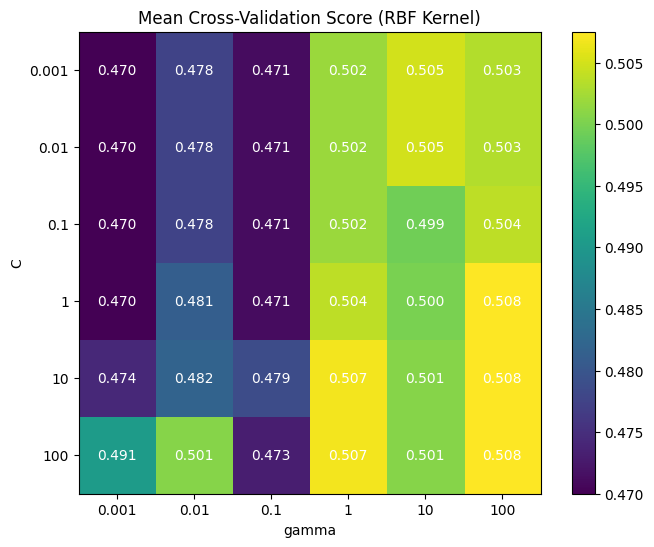

In [127]:
import matplotlib.pyplot as plt
rbf_results = results[results['param_kernel'] == 'rbf']
scores = np.array(rbf_results.mean_test_score).reshape(len(param_grid[0]['C']), len(param_grid[0]['gamma']))
plt.figure(figsize=(8, 6))
plt.imshow(scores, interpolation='nearest', cmap='viridis')
plt.xlabel('gamma')
plt.ylabel('C')
plt.colorbar()


plt.xticks(np.arange(len(param_grid[0]['gamma'])), param_grid[0]['gamma'])
plt.yticks(np.arange(len(param_grid[0]['C'])), param_grid[0]['C'])

for i in range(scores.shape[0]):
    for j in range(scores.shape[1]):
        plt.text(j, i, f'{scores[i, j]:.3f}', ha='center', va='center', color='white')

plt.title('Mean Cross-Validation Score (RBF Kernel)')
plt.show()

In [128]:
# creating the final model using obtained
model=SVC(**grid_search.best_params_)
model.fit(X_train,y_train)

SVC(C=1, gamma=100)

In [129]:
# test score
print(f"Test score: {model.score(X_test,y_test)}")

Test score: 0.495


In [130]:
y_pred=model.predict(X_test)

In [131]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.49      0.29      0.37       200
           1       0.50      0.69      0.58       200

    accuracy                           0.49       400
   macro avg       0.49      0.49      0.47       400
weighted avg       0.49      0.49      0.47       400



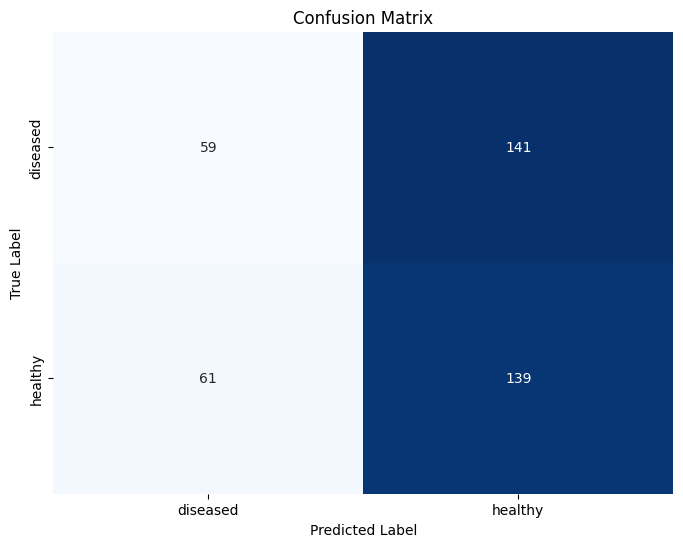

In [132]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['diseased', 'healthy'], yticklabels=['diseased', 'healthy'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()